In [1]:
%load_ext autoreload
%autoreload 2

from deep_bf.data_handler import DataLoader
import torch
import numpy as np
from tqdm import tqdm
import h5py
import hdf5plugin

data_path = "/home/panda/rf_data/dataset/raw"
img_path = "/home/panda/rf_data/dataset/img"

dl = DataLoader("/home/panda/rf_data/")

#nz = 2048
nz = 2048
nx = 256

#new_Ns = 2800
#new_Ns = 2300 #2294
new_Ns = 4096 #2294

device = "cuda"
dtype = torch.float32

In [2]:
df = dl.get_df()

df1 = df.query("RF == 1 and nc == 128")
df1 = df1[df1["name"].str[:3] != "JHU"]

query = "(RF == 1) and (nc == 128) and (name.str.slice(0, 3) != 'JHU')"
df2 = df.query(query)

print(df1.equals(df2))

#df = df[df["name"] != "OSL010"]
#df = df[df["name"].str[:3] != "UFL"] # UFL Por que es muy grande
# Agregar el OSL010

names = df["name"]

True


In [2]:
from deep_bf.wrapper.config import ConfigCenter, ExperimentPacking

cc = ConfigCenter()

experiment: ExperimentPacking = cc.get_experiment_config(id=0)
print(experiment.trainset)
print(experiment.webdataset)
print(experiment.model)
print(experiment.id)
print(experiment.seed)
print(experiment.version)
print(experiment.model.conv2d_config)

TrainSetPacking(training_config=TrainingConfig(id=0, n_epoch=100, batch_size=1, interval_epoch_save=5, seed=42), dataLoader_config=DataLoaderConfig(id=0, seed=42, num_workers=1, pin_memory=True), criterion_config=CriterionConfig(id=0, type='MSE', params={'reduction': 'mean'}), optimizer_config=OptimizerConfig(id=0, type='Adam', params={'lr': 0.001, 'betas': (0.9, 0.999), 'eps': 1e-07, 'weight_decay': 0.0, 'amsgrad': False}), scheduler_config=SchedulerConfig(id=0, type='ReduceLROnPlateau', params={'mode': 'min', 'factor': 0.5, 'patience': 5, 'threshold': 0.0001, 'min_lr': 1e-06}))
WebDatasetConfig(id=0, seed=42, mode='exact', transform='SHARIFZADEH', nz=2048, nx=256, ns=2800, ratio=0.9, order='CWH', n_dataset=550, n_train=495, n_val=55, query_filter="(RF == 1) and (nc == 128) and (name.str.slice(0, 3) != 'JHU')", single_filters=['contrast_speckle_expe_dataset_rf', 'contrast_speckle_simu_dataset_rf', 'resolution_distorsion_expe_dataset_rf', 'resolution_distorsion_simu_dataset_rf', 'carot

In [2]:
%load_ext autoreload
%autoreload 2

from deep_bf.data_handler import DataLoader
import torch
import numpy as np
from tqdm import tqdm
import os
from global_variables import *

In [3]:
from deep_bf.models import model_builder
from deep_bf.wrapper.config import ConfigCenter, PathCenter
from deep_bf.models.bf_layers.das import DAS

from dataclasses import astuple, asdict

experiment_id = 4
is_server = False
pc = PathCenter(is_server)

cc = ConfigCenter()
e = cc.get_experiment_config(id=experiment_id)

dataset_paths = pc.get_dataset_paths()

In [4]:
from deep_bf.dataset import GlobalSamplesIdx
gsi = GlobalSamplesIdx(dataset_paths.samples_idx, e.webdataset.query_filter)
print(gsi.samples_idx.shape)

loading gsi
gsi loaded
torch.Size([13, 128, 2048, 256])


In [8]:
from deep_bf.models.model_builder import model_builder
from deep_bf.models import DAS

mC = e.model
print(mC)
model_paths = pc.get_model_loading_paths(e, is_server=True)
print(model_paths.best)

model1 = model_builder(mC, gsi).to("cuda")
model2 = model_builder(mC, gsi).to("cuda")
#model = DAS(gsi)

ckpt = torch.load(f"{model_paths.best}/best.pt", map_location="cuda", weights_only=True)
model1.load_state_dict(ckpt["model_state"], strict=False)

ckpt2 = torch.load(f"{model_paths.best}/best.pt", map_location="cuda", weights_only=True)

ModelPacking(conv2d_config=Conv2dConfig(id=0, init_weights='XAVIER_UNIFORM', init_bias='ZEROS'), activation_config=ActivationConfig(id=0, type='LeakyReLU', params={'negative_slope': 0.01}), beamformer_config=BeamformerConfig(id=0, type='DAS', code_version=1), architecture_configs=[ArchitectureConfig(model_id=3, family='BINN_OG', pos=0, type='WConv2d', ch_in=1, ch_out=16, kernel=(5, 3), padding='same', bias=True), ArchitectureConfig(model_id=3, family='BINN_OG', pos=1, type='WConv2d', ch_in=16, ch_out=8, kernel=(5, 3), padding='same', bias=True), ArchitectureConfig(model_id=3, family='BINN_OG', pos=2, type='WBeamformer', ch_in=8, ch_out=8, kernel=(-1, -1), padding='same', bias=True), ArchitectureConfig(model_id=3, family='BINN_OG', pos=3, type='WConv2d', ch_in=8, ch_out=8, kernel=(5, 3), padding='same', bias=True), ArchitectureConfig(model_id=3, family='BINN_OG', pos=4, type='WConv2d', ch_in=8, ch_out=4, kernel=(5, 3), padding='same', bias=True), ArchitectureConfig(model_id=3, family='B

In [9]:
import zipfile
import h5py
import tempfile
import os
import json

keras_path = "./best_og.keras"
out_dir = "keras_dump"


weights = []
with zipfile.ZipFile(keras_path) as z:
    z.extract("metadata.json", out_dir)
    z.extract("config.json", out_dir)
    z.extract("model.weights.h5", out_dir)

    with open(f"{out_dir}/metadata.json", "r", encoding="utf-8") as f:
        metadata = json.load(f)

    with open(f"{out_dir}/config.json", "r", encoding="utf-8") as f:
        config = json.load(f)

    print(metadata)
    print(config)

    with h5py.File(f"{out_dir}/model.weights.h5", "r") as f:
        print(list(f.keys()))
        print(f["layers"].keys())
        print(f["layers"]["conv2d"].keys())

        layers = ['conv2d', 'conv2d_1', 'conv2d_2', 'conv2d_3', 'conv2d_4']
        for layer in layers:
            aux = f["layers"][layer]["vars"]
            w = aux["0"][:]
            b = aux["1"][:]
            weights.append((w,b))

        print(f["layers"]["conv2d"]["vars"]["0"][:].shape)
        print(f["layers"]["conv2d"]["vars"]["1"][:].shape)

        print(f["layers"]["das_beamform_layer"]["vars"])
        #print(f["layers"]["das_beamform_layer"]["vars"]["1"][:].shape)

        #print(f["vars"].keys())

        #print(f["optimizer"].keys())

{'keras_version': '3.6.0', 'date_saved': '2025-08-02@17:35:26'}
{'module': 'keras.src.models.functional', 'class_name': 'Functional', 'config': {'name': 'functional', 'trainable': True, 'layers': [{'module': 'keras.layers', 'class_name': 'InputLayer', 'config': {'batch_shape': [None, 128, 2800, 1], 'dtype': 'float32', 'sparse': False, 'name': 'rf'}, 'registered_name': None, 'name': 'rf', 'inbound_nodes': []}, {'module': 'keras.layers', 'class_name': 'Conv2D', 'config': {'name': 'conv0', 'trainable': True, 'dtype': {'module': 'keras', 'class_name': 'DTypePolicy', 'config': {'name': 'float32'}, 'registered_name': None, 'shared_object_id': 130604721791792}, 'filters': 16, 'kernel_size': [5, 3], 'strides': [1, 1], 'padding': 'same', 'data_format': 'channels_last', 'dilation_rate': [1, 1], 'groups': 1, 'activation': {'module': 'keras.layers', 'class_name': 'LeakyReLU', 'config': {'name': 'leaky_re_lu', 'trainable': True, 'dtype': {'module': 'keras', 'class_name': 'DTypePolicy', 'config': {'

In [11]:
py_layers = ["layers.0.conv2d", "layers.1.conv2d", "layers.3.conv2d", "layers.4.conv2d", "layers.5.conv2d"]

for i, (w, b) in enumerate(weights):
    w = torch.from_numpy(w).permute(3, 2, 0 ,1).contiguous().to("cuda")
    b = torch.from_numpy(b).contiguous().to("cuda")

    py_layer = py_layers[i]

    sw = f"{py_layer}.weight"
    sb = f"{py_layer}.bias"

    ckpt2["model_state"][sw] = w
    ckpt2["model_state"][sb] = b

model2.load_state_dict(ckpt2["model_state"], strict=False)


<All keys matched successfully>

In [5]:
from torchinfo import summary
from deep_bf.dataset.loader import get_datasets

e.trainset.training_config.batch_size = 1
train, val = get_datasets(dataset_paths.base_url, e.trainset)
it = iter(train)

sample = next(it)
rfs, ids, gt, name = sample
rfs = rfs.to(device="cuda")
ids = ids.to(device="cuda")

print(rfs.shape, ids.shape)

sum = summary(
    model, 
    input_size=[tuple(rfs.shape), tuple(ids.shape)],
    dtypes=[torch.float32, torch.long],
    device="cuda", 
    verbose=0,
    depth=4,
    col_names=("input_size", "output_size", "num_params", "kernel_size"),
    row_settings=("var_names", "depth")
)

print(sum)

torch.Size([1, 1, 128, 2800]) torch.Size([1])
Layer (type (var_name):depth-idx)             Input Shape               Output Shape              Param #                   Kernel Shape
BinnOG (BinnOG)                               [1, 1, 128, 2800]         [1, 1, 2048, 256]         --                        --
├─ModuleList (layers): 1-1                    --                        --                        --                        --
│    └─BasicConv2dModule (0): 2-1             [1, 1, 128, 2800]         [1, 16, 128, 2800]        --                        --
│    │    └─Conv2d (conv2d): 3-1              [1, 1, 128, 2800]         [1, 16, 128, 2800]        256                       [5, 3]
│    │    └─LeakyReLU (activation): 3-2       [1, 16, 128, 2800]        [1, 16, 128, 2800]        --                        --
│    └─BasicConv2dModule (1): 2-2             [1, 16, 128, 2800]        [1, 8, 128, 2800]         --                        --
│    │    └─Conv2d (conv2d): 3-3              [1, 1

In [29]:
import h5py
import hdf5plugin

#name = "contrast_speckle_expe_dataset_rf"
#name = "carotid_cross_expe_dataset_rf"
#name = "carotid_long_expe_dataset_rf"

name = "contrast_speckle_simu_dataset_rf"
#name = "MYO001"

#name = "TSH204"
#name = "UFL004"
wdC = e.webdataset

group = wdC.transform

nz = wdC.nz
nx = wdC.nx

pw = DL.get_defined_pwdata(name, "RF")

with h5py.File(f"{dataset_paths.raw}/{name}.hdf5", "r") as f:
    rf = f[f"{group}/rf"][:]
    gt = f[f"{group}/ground_truth_mvb"][:]

    print(rf.shape, gt.shape)

rfs = torch.from_numpy(rf).to("cuda").unsqueeze(0).unsqueeze(0)
ids = np.array([gsi[name]])
ids = torch.from_numpy(ids).to("cuda")

print(rf.shape, ids.shape)
model1.eval()
with torch.no_grad():
    output1 = model1(rfs, ids).squeeze().cpu()

model2.eval()
with torch.no_grad():
    output2 = model2(rfs, ids).squeeze().cpu()

(128, 2800) (2048, 256)
(128, 2800) torch.Size([1])


/tmp/ipykernel_543685/1074316102.py:29: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=0)


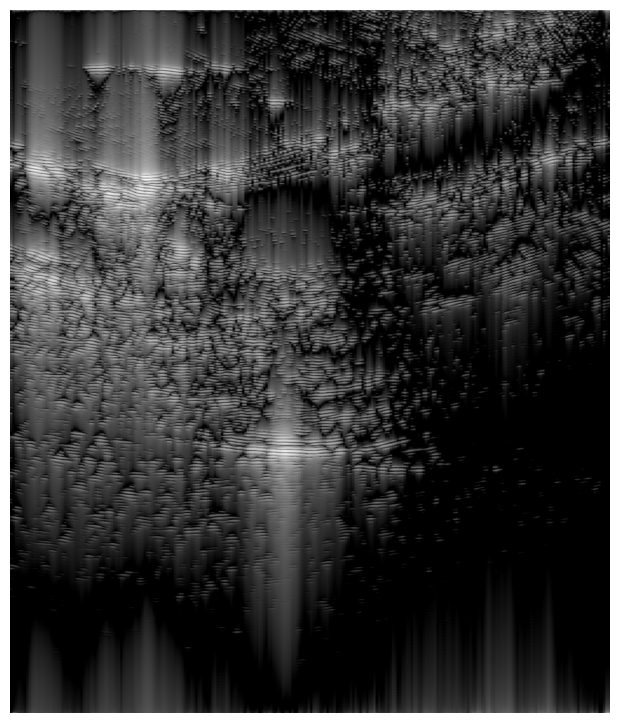

In [ ]:
import matplotlib.pyplot as plt
from deep_bf.beamformers import compute_meshgrid, get_rf_bmode

Z, X = compute_meshgrid(pw, nz, nx)

Z = Z.cpu()
X = X.cpu()

zlims = np.array([Z[0, 0], Z[-1, 0]]) * 1e3
xlims = np.array([X[0, 0], X[0, -1]]) * 1e3

vmin = -60
vmax = 0

b_mode1 = get_rf_bmode(output1, vmin, vmax)
b_mode2 = get_rf_bmode(output2, vmin, vmax)
b_mode_gt = get_rf_bmode(gt, vmin, vmax)

fig = plt.figure(figsize=(6, 8), frameon=False)
ax = fig.add_axes([0, 0, 1, 1])

extent = (xlims[0], xlims[-1], zlims[-1], zlims[0])

ax.imshow(b_mode1, cmap='gray', vmin=vmin, vmax=vmax,
          extent=extent,
          aspect='equal')
ax.set_axis_off()

plt.show()

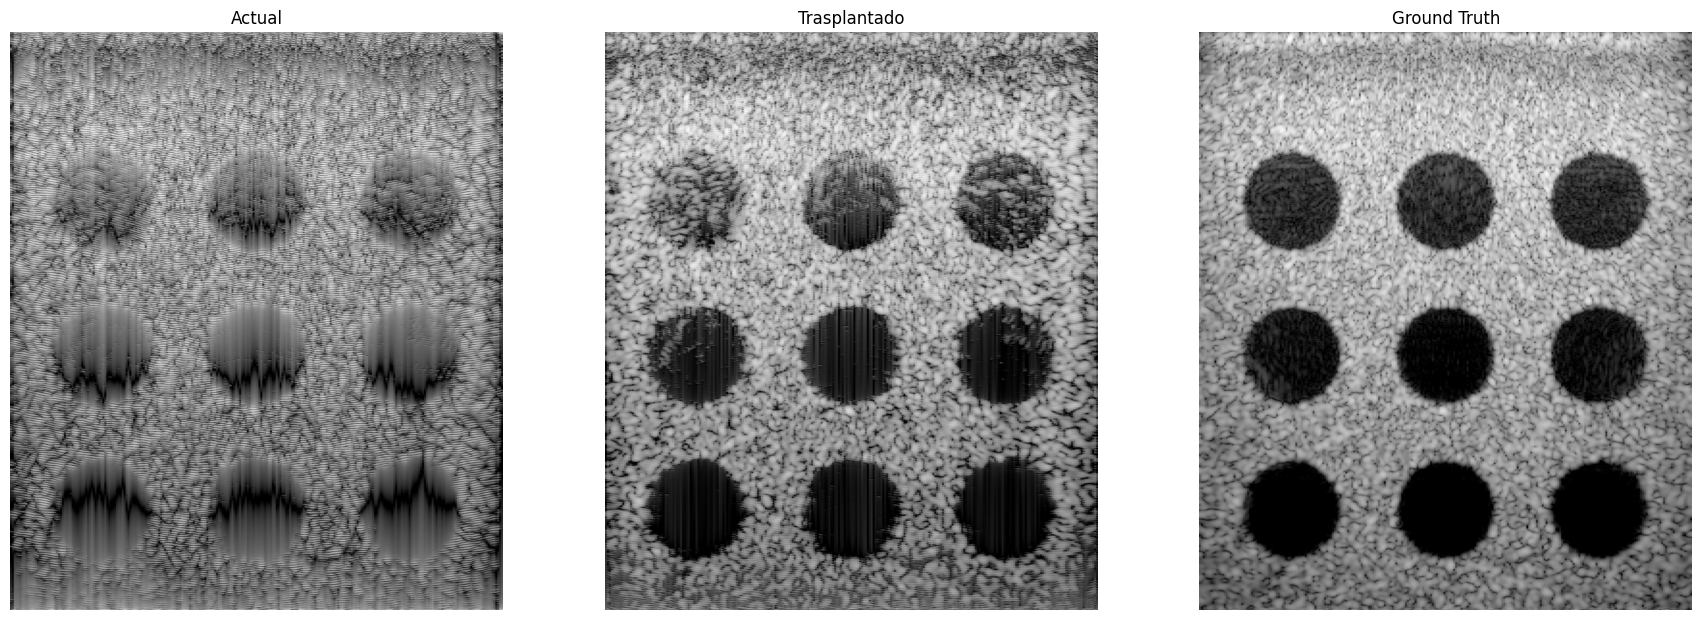

In [30]:
import matplotlib.pyplot as plt
from deep_bf.beamformers import compute_meshgrid, get_rf_bmode

Z, X = compute_meshgrid(pw, nz, nx)

Z = Z.cpu()
X = X.cpu()

zlims = np.array([Z[0, 0], Z[-1, 0]]) * 1e3
xlims = np.array([X[0, 0], X[0, -1]]) * 1e3

vmin = -60
vmax = 0

b_mode1 = get_rf_bmode(output1, vmin, vmax)
b_mode2 = get_rf_bmode(output2, vmin, vmax)
b_mode_gt = get_rf_bmode(gt, vmin, vmax)

fig, axes = plt.subplots(1, 3, figsize=(18, 6), frameon=False)

extent = (xlims[0], xlims[-1], zlims[-1], zlims[0])

for ax, img, title in zip(
    axes,
    [b_mode1, b_mode2, b_mode_gt],
    ["Actual", "Trasplantado", "Ground Truth"],
):
    ax.imshow(img, cmap="gray", vmin=vmin, vmax=vmax, extent=extent, aspect="equal")
    ax.set_title(title)
    ax.set_axis_off()

plt.tight_layout(pad=0)
plt.savefig(f"./{name}.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
import matplotlib.pyplot as plt
from deep_bf.beamformers import compute_meshgrid, get_rf_bmode

Z, X = compute_meshgrid(pw, nz, nx)

Z = Z.cpu()
X = X.cpu()

zlims = np.array([Z[0, 0], Z[-1, 0]]) * 1e3
xlims = np.array([X[0, 0], X[0, -1]]) * 1e3

vmin = -60
vmax = 0

fig = plt.figure(figsize=(8, 10), frameon=False)
ax = fig.add_axes([0, 0, 1, 1])

b_mode = get_rf_bmode(output, vmin, vmax)
#b_mode = get_rf_bmode(gt, vmin, vmax)

extent = (xlims[0], xlims[-1], zlims[-1], zlims[0])

ax.imshow(b_mode, cmap='gray', vmin=vmin, vmax=vmax,
          extent=extent,
          aspect='equal')
ax.set_axis_off()
plt.show()

In [ ]:
from deep_bf.dataset import get_datasets

train, val = get_datasets(dataset_paths.base_url, e.trainset)
it = iter(train)

i = 0
for sample in train:
    print(i, name)
    rfs, ids, gt, name = sample
    if name[0] == "contrast_speckle_expe_dataset_rf":
        print(name[0])
        rfs = rfs.to(device="cuda")
        ids = ids.to(device="cuda")

        model.eval()
        with torch.no_grad():
            output = model(rfs, ids).squeeze().cpu()
            gt = gt.squeeze().cpu()
        
        print(i)
        break
    i += 1

0 ['TSH056', 'TSH328']
1 ['OSL004', 'MYO006']
2 ['INS019', 'TSH068']
3 ['INS015', 'TSH058']
4 ['TSH409', 'TSH038']
5 ['INS012', 'TSH044']
6 ['TSH022', 'INS005']
7 ['INS004', 'TSH420']
8 ['MYO005', 'OSL002']
9 ['TSH032', 'TSH046']
10 ['TSH431', 'TSH040']
11 ['MYO003', 'TSH064']
12 ['TSH055', 'TSH061']
13 ['TSH418', 'TSH020']
14 ['TSH404', 'TSH025']
15 ['TSH448', 'INS002']
16 ['TSH006', 'TSH425']
17 ['TSH059', 'TSH469']
18 ['TSH005', 'TSH023']
19 ['TSH413', 'MYO004']
20 ['MYO001', 'TSH072']
21 ['MYO002', 'TSH452']
22 ['TSH060', 'TSH036']
23 ['TSH433', 'TSH446']
24 ['TSH491', 'TSH074']
25 ['TSH071', 'INS024']
26 ['TSH501', 'TSH424']
27 ['TSH066', 'TSH183']
28 ['TSH016', 'TSH407']
29 ['UFL003', 'TSH026']
30 ['TSH043', 'TSH184']
31 ['TSH027', 'TSH450']
32 ['TSH492', 'TSH480']
33 ['TSH444', 'TSH216']
34 ['TSH067', 'TSH007']
35 ['TSH415', 'TSH063']
36 ['TSH461', 'TSH037']
37 ['TSH222', 'INS020']
38 ['TSH199', 'TSH219']
39 ['TSH009', 'TSH489']
40 ['TSH030', 'TSH223']
41 ['TSH449', 'TSH212']
42

In [38]:
output.shape

NameError: name 'output' is not defined

NameError: name 'output' is not defined

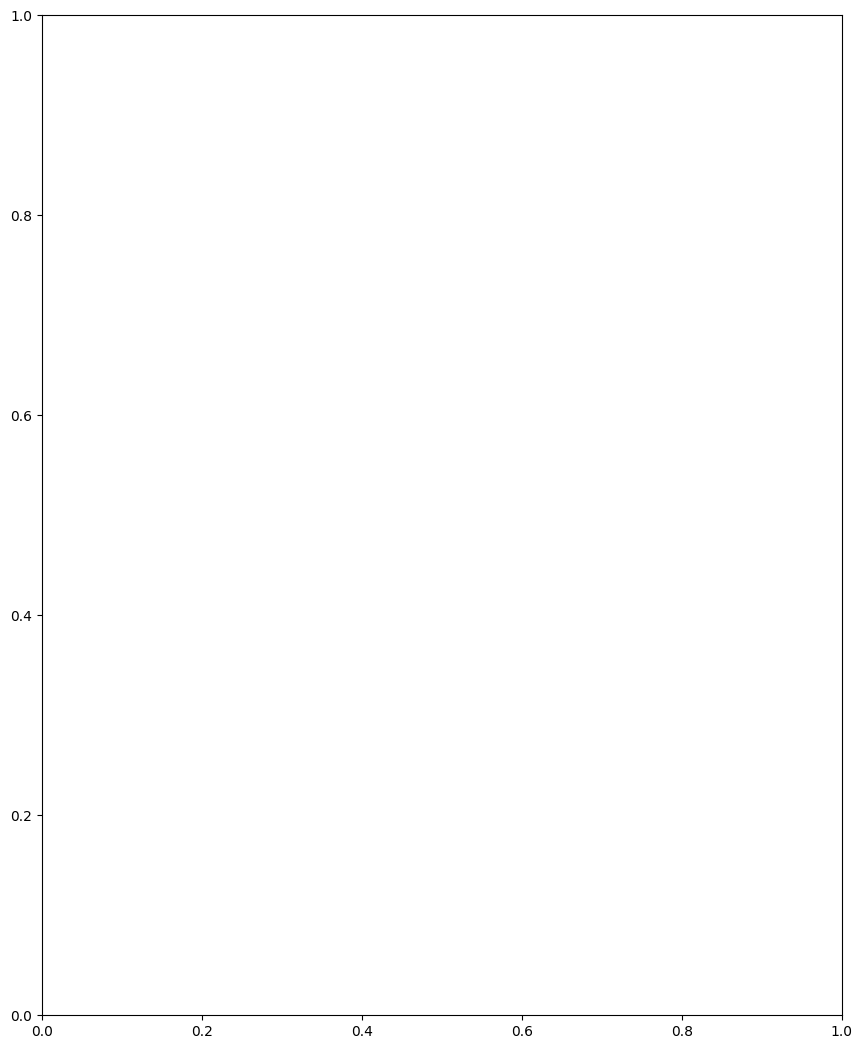

In [37]:
import matplotlib.pyplot as plt
from deep_bf.beamformers import compute_meshgrid, get_rf_bmode

# TODO: Sacar el zlims, xlims con el samples_idx

pw = DL.get_defined_pwdata("contrast_speckle_expe_dataset_rf", "RF")
nz = 2048
nx = 256
Z, X = compute_meshgrid(pw, nz, nx)

Z = Z.cpu()
X = X.cpu()

zlims = np.array([Z[0, 0], Z[-1, 0]]) * 1e3
xlims = np.array([X[0, 0], X[0, -1]]) * 1e3

vmin = -60
vmax = 0

fig = plt.figure(figsize=(8, 10), frameon=False)
ax = fig.add_axes([0, 0, 1, 1])

b_mode = get_rf_bmode(output, vmin, vmax)
#b_mode = get_rf_bmode(gt, vmin, vmax)

extent = (xlims[0], xlims[-1], zlims[-1], zlims[0])

ax.imshow(b_mode, cmap='gray', vmin=vmin, vmax=vmax,
          extent=extent,
          aspect='equal')
ax.set_axis_off()
plt.show()

In [2]:
from deep_bf.wrapper.config import ConfigCenter
from deep_bf.dataset.create import create_dataset
from global_variables import get_global_paths, RAW_PATH

paths = get_global_paths(server=False)

cc = ConfigCenter()
e = cc.get_experiment_config(id=1)

print(e.webdataset)
create_dataset(RAW_PATH, paths["base_url"], paths["samples_idx"], e.webdataset)


WebDatasetConfig(id=1, seed=42, mode='select', transform='sharifzadeh', nz=2048, nx=256, ns=2800, ratio=0.9, order='CWH', n_dataset=550, n_train=495, n_val=55, query_filter="(RF == 1) and (nc == 128) and (name.str.slice(0, 3) != 'JHU')", single_filters=[], train_files=['INS001', 'INS002', 'INS003', 'INS004', 'INS005', 'INS006', 'INS007', 'INS008', 'INS009', 'INS010', 'INS011', 'INS012', 'INS013', 'INS015', 'INS016', 'INS017', 'INS018', 'INS019', 'INS020', 'INS023', 'INS024', 'INS025', 'INS026', 'MYO001', 'MYO002', 'MYO003', 'MYO004', 'MYO005', 'MYO006', 'OSL002', 'OSL003', 'OSL004', 'OSL005', 'OSL006', 'OSL007', 'OSL010', 'TSH002', 'TSH003', 'TSH004', 'TSH005', 'TSH006', 'TSH007', 'TSH008', 'TSH009', 'TSH010', 'TSH011', 'TSH012', 'TSH013', 'TSH014', 'TSH016', 'TSH017', 'TSH018', 'TSH019', 'TSH020', 'TSH022', 'TSH023', 'TSH024', 'TSH025', 'TSH026', 'TSH027', 'TSH028', 'TSH029', 'TSH030', 'TSH031', 'TSH032', 'TSH033', 'TSH035', 'TSH036', 'TSH037', 'TSH038', 'TSH039', 'TSH040', 'TSH041', 

In [20]:
import h5py
import hdf5plugin
import numpy as np

name = "TSH501"

def transform(rf):
    rf_max = rf / np.max(np.abs(rf))
    sigma = np.std(rf_max) + 1e-4
    rf = rf_max / sigma

    return rf

from deep_bf.dataset.write import upscale_data

with h5py.File(f"/home/panda/rf_data/dataset/raw/{name}.hdf5", "r") as f:
    print(list(f.keys()))
    g = f.require_group("sharifzadeh")
    #g = f.require_group("none")

    print(list(g.keys()))
    rf1 = g["rf"][:]
    rf1 = transform(rf1)
    rf1 = upscale_data(rf1, 2800)

    gt1 = g["ground_truth_mvb"][:]


with h5py.File(f"/home/panda/rf_data/dl_data/{name}.hdf5", "r") as f:
    print(list(f.keys()))
    rf2 = f["rfdata"][:]
    gt2 = f["img"][:]


print(rf1.shape)
print(rf2.shape)

print(np.array_equal(rf1, rf2))
print(np.allclose(rf1, rf2))

print(rf1[0: 1: ])
print(rf2[0: 1: ])

print(gt1.shape)
print(gt2.shape)

print(np.array_equal(gt1, gt2))
print(np.allclose(gt1, gt2))

print(gt1[0, 0:10])
print(gt2[0, 0:10])




['none', 'sharifzadeh']
['ground_truth_mvb', 'rf']
['grid', 'img', 'probe_geometry', 'rfdata']
(128, 2800)
(128, 2800)
False
False
[[ 0.12296192  0.36515966 -0.19748431 ...  0.          0.
   0.        ]]
[[ 0.11427551  0.33936363 -0.18353339 ...  0.          0.
   0.        ]]
(2048, 256)
(2048, 256)
False
False
[-0.03559777  0.1773237  -0.47973526  0.389484   -0.4560925   0.5533163
 -0.12005109  0.01530433  0.09350368  0.00070156]
[-0.00136322  0.00659825 -0.01814121  0.01463003 -0.01723597  0.02088974
 -0.00451655  0.00053396  0.00357232  0.00011747]


In [24]:
import zipfile
import h5py
import tempfile
import os
import json

keras_path = "./best_og.keras"
out_dir = "keras_dump"


weights = []
with zipfile.ZipFile(keras_path) as z:
    z.extract("metadata.json", out_dir)
    z.extract("config.json", out_dir)
    z.extract("model.weights.h5", out_dir)

    with open(f"{out_dir}/metadata.json", "r", encoding="utf-8") as f:
        metadata = json.load(f)

    with open(f"{out_dir}/config.json", "r", encoding="utf-8") as f:
        config = json.load(f)

    print(metadata)
    print(config)

    with h5py.File(f"{out_dir}/model.weights.h5", "r") as f:
        print(list(f.keys()))
        print(f["layers"].keys())
        print(f["layers"]["conv2d"].keys())

        layers = ['conv2d', 'conv2d_1', 'conv2d_2', 'conv2d_3', 'conv2d_4']
        for layer in layers:
            aux = f["layers"][layer]["vars"]
            w = aux["0"][:]
            b = aux["1"][:]
            weights.append((w,b))

        print(f["layers"]["conv2d"]["vars"]["0"][:].shape)
        print(f["layers"]["conv2d"]["vars"]["1"][:].shape)

        print(f["layers"]["das_beamform_layer"]["vars"])
        #print(f["layers"]["das_beamform_layer"]["vars"]["1"][:].shape)

        #print(f["vars"].keys())

        #print(f["optimizer"].keys())

{'keras_version': '3.6.0', 'date_saved': '2025-08-02@17:35:26'}
{'module': 'keras.src.models.functional', 'class_name': 'Functional', 'config': {'name': 'functional', 'trainable': True, 'layers': [{'module': 'keras.layers', 'class_name': 'InputLayer', 'config': {'batch_shape': [None, 128, 2800, 1], 'dtype': 'float32', 'sparse': False, 'name': 'rf'}, 'registered_name': None, 'name': 'rf', 'inbound_nodes': []}, {'module': 'keras.layers', 'class_name': 'Conv2D', 'config': {'name': 'conv0', 'trainable': True, 'dtype': {'module': 'keras', 'class_name': 'DTypePolicy', 'config': {'name': 'float32'}, 'registered_name': None, 'shared_object_id': 130604721791792}, 'filters': 16, 'kernel_size': [5, 3], 'strides': [1, 1], 'padding': 'same', 'data_format': 'channels_last', 'dilation_rate': [1, 1], 'groups': 1, 'activation': {'module': 'keras.layers', 'class_name': 'LeakyReLU', 'config': {'name': 'leaky_re_lu', 'trainable': True, 'dtype': {'module': 'keras', 'class_name': 'DTypePolicy', 'config': {'

In [25]:
#print(len(weights))
#print(weights[0][0].shape)
#print(weights[0][1].shape)

#print(weights[0][0].transpose().shape)
py_layers = ["layers.0.conv2d", "layers.1.conv2d", "layers.3.conv2d", "layers.4.conv2d", "layers.5.conv2d"]

for i, (w, b) in enumerate(weights):
    w = torch.from_numpy(w).permute(3, 2, 0 ,1).contiguous().to("cuda")
    b = torch.from_numpy(b).contiguous().to("cuda")

    py_layer = py_layers[i]

    sw = f"{py_layer}.weight"
    sb = f"{py_layer}.bias"

    ckpt["model_state"][sw] = w
    ckpt["model_state"][sb] = b


In [15]:
print(list(ckpt["model_state"].keys()))
print(ckpt["model_state"]["layers.0.conv2d.weight"].shape)
print(ckpt["model_state"]["layers.0.conv2d.bias"].shape)

['layers.0.conv2d.weight', 'layers.0.conv2d.bias', 'layers.1.conv2d.weight', 'layers.1.conv2d.bias', 'layers.3.conv2d.weight', 'layers.3.conv2d.bias', 'layers.4.conv2d.weight', 'layers.4.conv2d.bias', 'layers.5.conv2d.weight', 'layers.5.conv2d.bias']
torch.Size([16, 1, 5, 3])
torch.Size([16])
